<div style="border: 2px solid #000; padding: 15px; text-align: center; font-family: Arial, sans-serif;">
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQjQvWlCSzjP9LkY3M1d439hzZbHqbSNvI5Sw&s" alt="Logo" style="float: right; width: 50px; height: auto;">
    <h3>Institut Supérieur des Arts Multimédia de la Manouba</h3>
    <h1>Projet Fraisa Monte Carlo  </h1>
    <table style="margin: 10px auto; width: 80%; border-collapse: collapse;">
        <tr>
            <td style="border: 1px solid #000; padding: 5px;"><b>nom:</b></td>
            <td style="border: 1px solid #000; padding: 5px;">Yosr Meddah</td>
        </tr>
        <tr>
            <td style="border: 1px solid #000; padding: 5px;"><b>Classe:</b></td>
            <td style="border: 1px solid #000; padding: 5px;">1ére Ingénieurie 1</td>
        </tr>
        <tr>
            <td style="border: 1px solid #000; padding: 5px;"><b>Professeur:</b></td>
            <td style="border: 1px solid #000; padding: 5px;">M.Ibrahim Trabelsi</td>
        </tr>
        <tr>
            <td style="border: 1px solid #000; padding: 5px;"><b>Sujet:</b></td>
            <td style="border: 1px solid #000; padding: 5px;">Simulation des Interactions avec Fraisa : Comprendre les Comportements et les Stratégies Humaines</td>
        </tr>
    </table>
    
</div>


<h1 style="color: red;">Imports</h1>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

## Style de Graphiques 

In [5]:
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})


<h1 style="color: red;"> class FraisaInteractionSimulation </h1>


In [6]:
class FraisaInteractionSimulation:
    def __init__(self):
        self.factors = {
            'temps_exposition': {
                'poids': 0.3,  
                'max_impact': 0.7 
            },
            'niveau_sonore': {
                'poids': 0.2,  
                'preference': 'calme'  
            },
            'type_interaction': {
                'classement': {
                    'ignorer': -0.3,
                    'appater': 0.1,
                    'nourrir': 0.5,
                    'caresser_doucement': 0.4
                }
            },
            'odeur': {
                'facteurs_repulsifs': ['parfum fort', 'odeur animale agressive']
            },
            'experience_passee': {
                'memoire_negative_impact': -0.4  
            }
        }
        
        
        self.tolerance = 0 
        self.interactions_historique = []
        
       
        self.personality = {
            'curiosity': random.uniform(0.5, 0.9),  
            'shyness': random.uniform(0.2, 0.6),      
            'hunger_influence': random.uniform(0.3, 0.7)  
        }
        
       
        self.habituation_rate = 0.05  # plus la valeur augmente, plus fraisa s'habitue facilement aux personnes 
        
        #  rang de 0 à 1, 0 très négatif, 1 positif
        self.mood = 0.5 

    def calculer_probabilite_interaction(self, parametres):
        """
        Calculates the acceptance probability based on different factors.
        """
        probabilite = 0
        
        # Impact du temps
        temps = parametres.get('temps_exposition', 0)
        temps_impact = min(temps * self.factors['temps_exposition']['poids'], self.factors['temps_exposition']['max_impact'])
        probabilite += temps_impact
        
        # Impact du niveau sonore
        if parametres.get('niveau_sonore', 'moyen') == 'calme':
            probabilite += self.factors['niveau_sonore']['poids']
        
        # Impact du type d'interaction
        interaction = parametres.get('type_interaction', 'ignorer')
        probabilite += self.factors['type_interaction']['classement'].get(interaction, 0)
        
        # l'odeur
        if any(odeur in parametres.get('odeurs', []) for odeur in self.factors['odeur']['facteurs_repulsifs']):
            probabilite -= 0.3
        
        # l'effet de la mémoire
        if parametres.get('a_fui_precedemment', False):
            jours = parametres.get('jours_depuis_derniere_visite', 1)
            decay = np.exp(-jours / 30)  # A decay constant: negative impact fades with time
            probabilite += self.factors['experience_passee']['memoire_negative_impact'] * decay
        
        # l'effet du temps dans le jour
        time_of_day = parametres.get('time_of_day', 'afternoon')
        time_effects = {
            'early_morning': 0.1,
            'morning': -0.1,
            'afternoon': -0.2,
            'evening': 0.3,
            'night': 0.2
        }
        probabilite += time_effects.get(time_of_day, 0)
        
        # les facteurs d'environnement 
        if 'facteurs_environnement' in parametres:
            if 'nouveaux_meubles' in parametres['facteurs_environnement']:
                probabilite -= 0.15
            if 'territoire_familier' in parametres['facteurs_environnement']:
                probabilite += 0.2
            if 'presence_autres_animaux' in parametres['facteurs_environnement']:
                probabilite -= 0.25
        
        # la probabilité augemente selon le nombre de rencontres
        if 'nombre_rencontres_precedentes' in parametres:
            habituation_effect = min(0.4, self.habituation_rate * parametres['nombre_rencontres_precedentes'])
            probabilite += habituation_effect
        
        # effet du temps dès la derniere visite
        if 'jours_depuis_derniere_visite' in parametres:
            jours = parametres['jours_depuis_derniere_visite']
            if jours > 30:
                probabilite -= 0.15
            elif jours < 3:
                probabilite += 0.1
                
        # caractère de Fraisa
        probabilite += (self.personality['curiosity'] - 0.4) * 0.2  
        probabilite -= self.personality['shyness'] * 0.3  
        
        # faim
        if interaction == 'nourrir':
            faim = parametres.get('niveau_faim', 0.5)
            probabilite += faim * self.personality['hunger_influence']
                
        # comportements des humains
        if parametres.get('proche_du_siège', False):
            probabilite -= 0.2
        if parametres.get('touche_les_jouets', False):
            probabilite -= 0.15
        if parametres.get('parle_trop', False):
            probabilite -= 0.1
        if parametres.get('respecte_intimité', True):
            probabilite += 0.1
        else:
            probabilite -= 0.1
        
        # Influence du mood de Fraisa
        probabilite += (self.mood - 0.5) * 0.2

        # MAJ le mood
        self.mood = np.clip(self.mood + (probabilite - 0.5) * 0.05, 0, 1)
        probabilite = max(0, min(1, probabilite))
        return probabilite
    
    def simuler_interactions(self, nombre_interactions=1000):
        """
        Monte Carlo simulation of random interactions.
        """
        resultats = []
        for _ in range(nombre_interactions):
            parametres = {
                'temps_exposition': random.uniform(0, 10),
                'niveau_sonore': random.choice(['calme', 'moyen', 'bruyant']),
                'type_interaction': random.choice(['ignorer', 'appater', 'nourrir', 'caresser_doucement']),
                'odeurs': random.sample(['parfum', 'neutre', 'animale', 'parfum fort', 'odeur animale agressive'], random.randint(0, 2)),
                'a_fui_precedemment': random.choice([True, False]),
                'time_of_day': random.choice(['early_morning', 'morning', 'afternoon', 'evening', 'night']),
                'niveau_faim': random.uniform(0, 1),
                'facteurs_environnement': random.sample(['nouveaux_meubles', 'territoire_familier', 'presence_autres_animaux'], random.randint(0, 2)),
                'proche_du_siège': random.choice([True, False]),
                'touche_les_jouets': random.choice([True, False]),
                'parle_trop': random.choice([True, False]),
                'respecte_intimité': random.choice([True, False])
            }
            probabilite = self.calculer_probabilite_interaction(parametres)
            resultats.append(probabilite)
        return resultats
    
    def simuler_interactions_multiple_sessions(self, nombre_personnes=20, sessions_par_personne=5):
        """
        Simulate repeated interactions with the same persons across multiple sessions.
        """
        resultats_par_personne = []
        for i in range(nombre_personnes):
            personne_resultats = []
            memoire_negative = False
            nombre_rencontres = 0
            for session in range(sessions_par_personne):
                nombre_rencontres += 1
                jours_depuis_visite = random.randint(1, 60)
                parametres = {
                    'temps_exposition': random.uniform(0, 10),
                    'niveau_sonore': random.choice(['calme', 'moyen', 'bruyant']),
                    'type_interaction': random.choice(['ignorer', 'appater', 'nourrir', 'caresser_doucement']),
                    'odeurs': random.sample(['parfum', 'neutre', 'animale', 'parfum fort', 'odeur animale agressive'], random.randint(0, 2)),
                    'a_fui_precedemment': memoire_negative,
                    'nombre_rencontres_precedentes': nombre_rencontres,
                    'jours_depuis_derniere_visite': jours_depuis_visite,
                    'time_of_day': random.choice(['early_morning', 'morning', 'afternoon', 'evening', 'night']),
                    'niveau_faim': random.uniform(0, 1),
                    'facteurs_environnement': random.sample(['nouveaux_meubles', 'territoire_familier', 'presence_autres_animaux'], random.randint(0, 2)),
                    'proche_du_siège': random.choice([True, False]),
                    'touche_les_jouets': random.choice([True, False]),
                    'parle_trop': random.choice([True, False]),
                    'respecte_intimité': random.choice([True, False])
                }
                probabilite = self.calculer_probabilite_interaction(parametres)
                personne_resultats.append(probabilite)
                if random.random() > probabilite:
                    memoire_negative = True
                else:
                    memoire_negative = False
            resultats_par_personne.append(personne_resultats)
        return resultats_par_personne
    
    def simuler_strategies_humaines(self, nombre_simulations=100):
        """
        Test different human approach strategies.
        """
        strategies = {
            'direct': {'temps_exposition': 10, 'niveau_sonore': 'moyen', 'type_interaction': 'caresser_doucement'},
            'patient': {'temps_exposition': 2, 'niveau_sonore': 'calme', 'type_interaction': 'ignorer'},
            'nourriture': {'temps_exposition': 5, 'niveau_sonore': 'calme', 'type_interaction': 'nourrir'},
            'joueur': {'temps_exposition': 7, 'niveau_sonore': 'moyen', 'type_interaction': 'appater'}
        }
        resultats = {}
        for nom, strategie in strategies.items():
            probs = []
            for i in range(nombre_simulations):
                parametres = strategie.copy()
                parametres.update({
                    'odeurs': random.sample(['parfum', 'neutre', 'animale', 'parfum fort', 'odeur animale agressive'], random.randint(0, 2)),
                    'a_fui_precedemment': random.choice([True, False]),
                    'time_of_day': random.choice(['early_morning', 'morning', 'afternoon', 'evening', 'night']),
                    'niveau_faim': random.uniform(0, 1),
                    'facteurs_environnement': random.sample(['nouveaux_meubles', 'territoire_familier', 'presence_autres_animaux'], random.randint(0, 2)),
                    'proche_du_siège': random.choice([True, False]),
                    'touche_les_jouets': random.choice([True, False]),
                    'parle_trop': random.choice([True, False]),
                    'respecte_intimité': random.choice([True, False])
                })
                probs.append(self.calculer_probabilite_interaction(parametres))
            resultats[nom] = probs
        return resultats


<h1 style="color: red;">Generation des graphiques</h1>


In [7]:
simulation = FraisaInteractionSimulation()
resultats = simulation.simuler_interactions(nombre_interactions=5000)
def generer_graphiques_detailles(resultats):
    plt.figure(figsize=(15, 10))

## Subplot 1 - Tolérance Cumulée

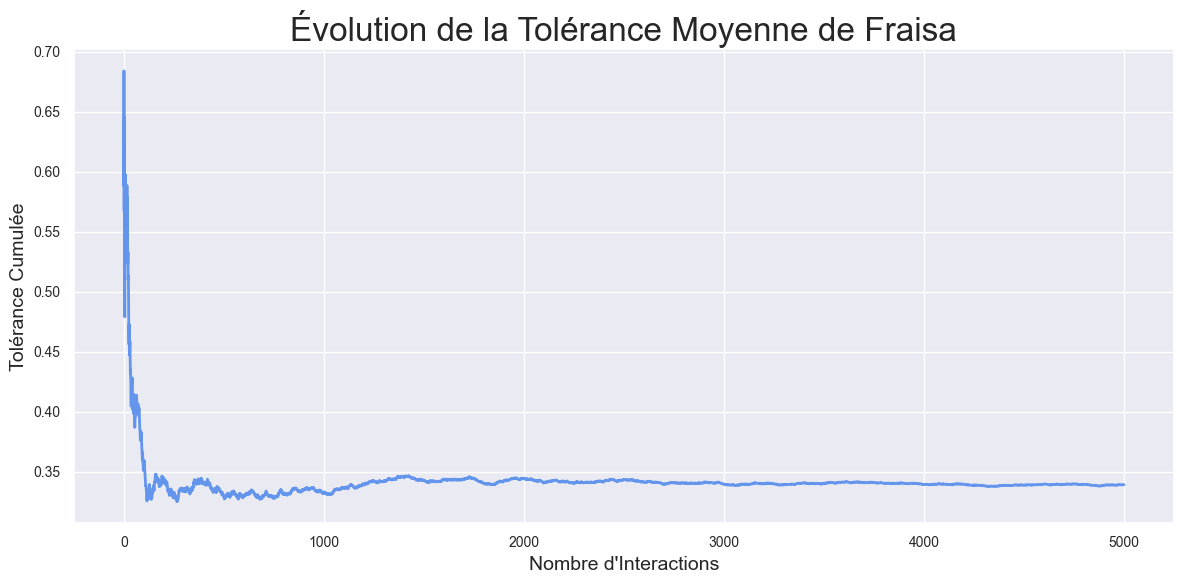

In [8]:
moyennes_cumulatives = np.cumsum(resultats) / np.arange(1, len(resultats) + 1)


plt.figure(figsize=(12, 6))  # Same size as the histogram for consistency


plt.plot(moyennes_cumulatives, color='cornflowerblue', linewidth=2)


plt.title("Évolution de la Tolérance Moyenne de Fraisa", fontsize=24)

plt.xlabel("Nombre d'Interactions", fontsize=14)
plt.ylabel("Tolérance Cumulée", fontsize=14)


plt.grid(True)
plt.tight_layout()


plt.show()

 Le graphique présente l’évolution de la moyenne cumulative de la tolérance de Fraisa en fonction du nombre d’interactions. On observe une convergence progressive vers une valeur stable, ce qui illustre la loi des grands nombres : à mesure que le nombre d’interactions augmente, la moyenne empirique tend vers l’espérance mathématique de la variable aléatoire « tolérance ».



## Subplot 2 - Distribution des Probabilités d'Acceptation

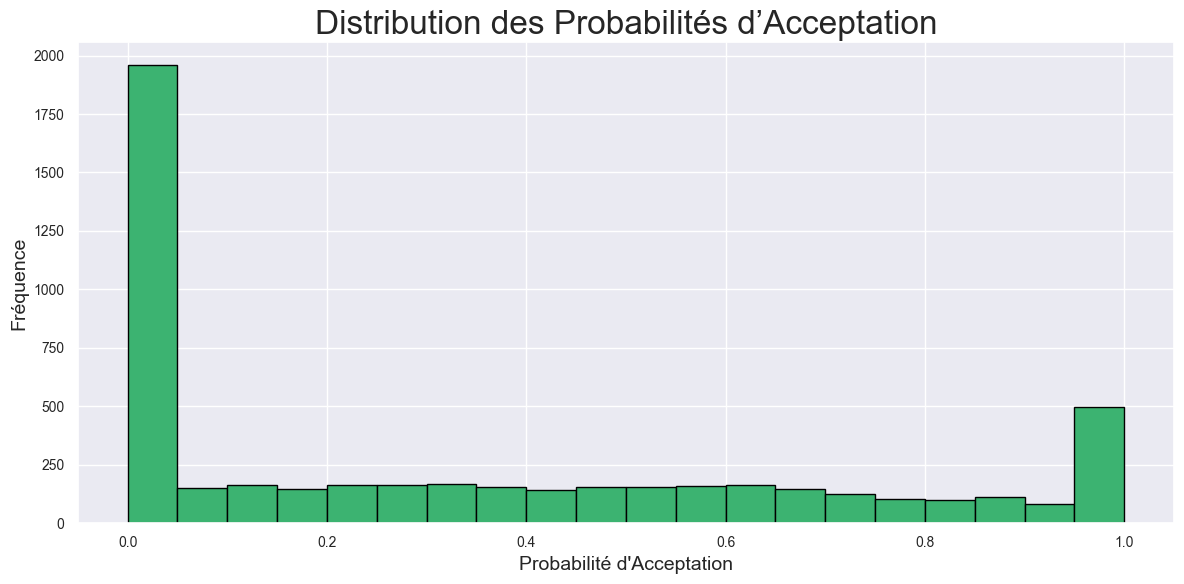

In [9]:

plt.figure(figsize=(12, 6)) 


plt.hist(resultats, bins=20, color='mediumseagreen', edgecolor='black')


plt.title('Distribution des Probabilités d’Acceptation', fontsize=24)
plt.xlabel("Probabilité d'Acceptation", fontsize=14)
plt.ylabel('Fréquence', fontsize=14)


plt.grid(True)
plt.tight_layout()  


plt.show()


Ce graphique représente l’histogramme de la distribution des probabilités d’acceptation de Fraisa. On observe une concentration des valeurs autour de 0 (rejets fréquents) et 1 (acceptations rares mais franches), indiquant une variable aléatoire souvent polarisée, avec peu de cas d’acceptation partielle. Cette distribution suggère un comportement plutôt binaire.

## Subplot 3 - Boxplot des Probabilités d'Acceptation

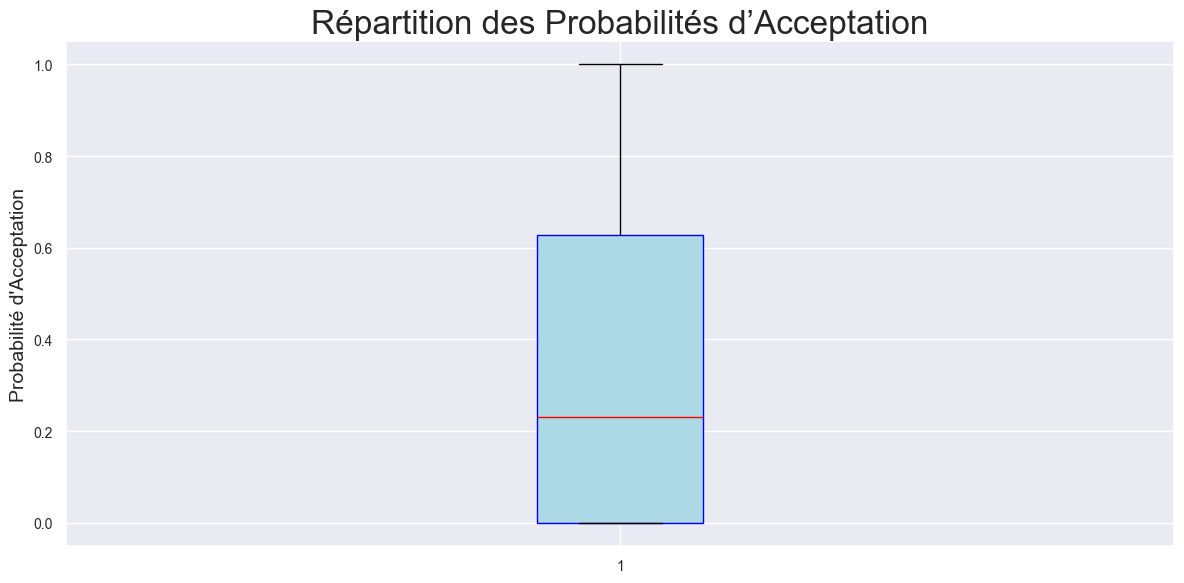

In [10]:
plt.figure(figsize=(12, 6))  # Largeur de 12 pouces et hauteur de 7 pouces


plt.boxplot(resultats,
            patch_artist=True,  # Remplir les boîtes avec de la couleur
            boxprops=dict(facecolor='lightblue', color='blue'),  # Couleur de la boîte
            medianprops=dict(color='red'))  # Couleur de la médiane

#
plt.title('Répartition des Probabilités d’Acceptation', fontsize=24)
plt.ylabel("Probabilité d'Acceptation", fontsize=14)


plt.grid(True)


plt.tight_layout()


plt.show()

 Ce diagramme en boîte illustre la distribution des probabilités d'acceptation pour Fraisa. La médiane est inférieure à 0,2, ce qui indique que l'acceptation est généralement faible. L'écart interquartile (IQR) couvre une large gamme, suggérant une grande variabilité dans les réponses. Le moustache supérieur atteint près de 1, montrant que, bien que rares, des probabilités d'acceptation élevées se produisent.




## Subplot 4 - Tendance des 100 Dernières Interactions

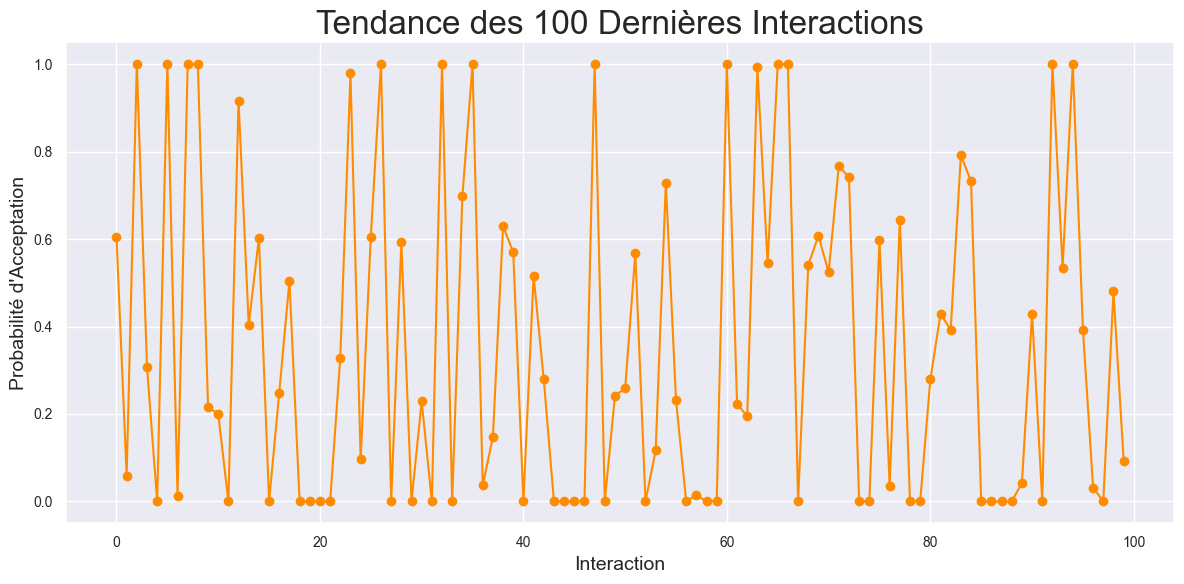

In [11]:
dernieres_interactions = resultats[-100:] if len(resultats) >= 100 else resultats

plt.figure(figsize=(12, 6))  # Largeur de 12 pouces et hauteur de 7 pouces

plt.plot(dernieres_interactions, color='darkorange', marker='o')

plt.title('Tendance des 100 Dernières Interactions', fontsize=24)
plt.xlabel('Interaction', fontsize=14)
plt.ylabel("Probabilité d'Acceptation", fontsize=14)

plt.grid(True)

plt.tight_layout()

plt.show()

Ce graphique en ligne illustre la tendance des probabilités d'acceptation pour les 100 dernières interactions. La variabilité est très élevée, avec des valeurs oscillant entre 0 et 1. Les nombreux pics proches de 1 indiquent que des probabilités d'acceptation élevées se produisent fréquemment, tandis que les creux marqués montrent que certaines interactions présentent des probabilités d'acceptation très faibles. Cette distribution aléatoire témoigne d'une grande hétérogénéité dans les résultats.

## Affichage des Statistiques Supplémentaires

In [12]:
def afficher_statistiques(resultats):
    print(f"Probabilité moyenne d'acceptation : {np.mean(resultats)*100:.2f}%")
    print(f"Écart-type des interactions : {np.std(resultats)*100:.2f}%")
    print(f"Probabilité minimale : {min(resultats)*100:.2f}%")
    print(f"Probabilité maximale : {max(resultats)*100:.2f}%")
    print(f"Médiane : {np.median(resultats)*100:.2f}%")
    print(f"25ème percentile : {np.percentile(resultats, 25)*100:.2f}%")
    print(f"75ème percentile : {np.percentile(resultats, 75)*100:.2f}%")


## Exécution des fonctions

In [13]:

generer_graphiques_detailles(resultats)
afficher_statistiques(resultats)


Probabilité moyenne d'acceptation : 33.91%
Écart-type des interactions : 35.57%
Probabilité minimale : 0.00%
Probabilité maximale : 100.00%
Médiane : 23.03%
25ème percentile : 0.00%
75ème percentile : 62.90%


<Figure size 1500x1000 with 0 Axes>

<h1 style="color: red;">Stratégie d'analyse et visualisation</h1>


In [14]:
resultats_strategies = simulation.simuler_strategies_humaines(nombre_simulations=200)

def analyser_strategies(resultats_strategies):
    plt.figure(figsize=(12, 8))
    

## Comparaison des differentes stratégies 

C:\Users\yosr\AppData\Local\Temp\ipykernel_8156\3550044179.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=labels, patch_artist=True,


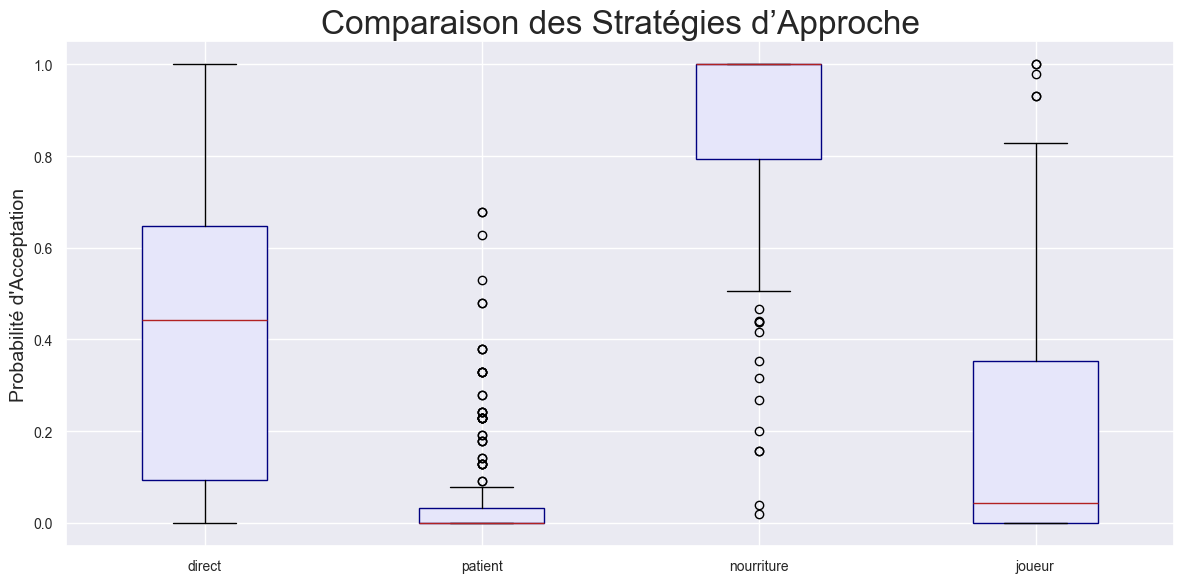

In [15]:
labels = list(resultats_strategies.keys())
data_box = [values for values in resultats_strategies.values()]

plt.figure(figsize=(12, 6))  # Increase the figure size

plt.boxplot(data_box, labels=labels, patch_artist=True,
            boxprops=dict(facecolor='lavender', color='navy'),  # Customize the box color and border
            medianprops=dict(color='firebrick'))  # Customize the median line color

plt.title("Comparaison des Stratégies d’Approche", fontsize=24)
plt.ylabel("Probabilité d'Acceptation", fontsize=14)

plt.grid(True)

plt.tight_layout()

plt.show()

Ce diagramme en boîte compare les probabilités d'acceptation pour différentes stratégies d'approche. Voici les observations spécifiques pour chaque stratégie:

Stratégie "direct" : Les probabilités d'acceptation sont moyennes, avec une médiane modérée et une variabilité notable (écart interquartile visible). Quelques valeurs extrêmes sont présentes.

Stratégie "patient" : Cette stratégie affiche des probabilités faibles et peu variables, avec une médiane proche du bas de l'échelle. Elle semble être la moins efficace.

Stratégie "nourriture" : C’est la stratégie la plus prometteuse. Sa médiane est élevée, et bien qu’elle présente une grande variabilité, ses moustaches atteignent des probabilités très élevées (près de 1). Cela indique que cette méthode peut être très performante dans de nombreux cas.

Stratégie "joueur" : Les probabilités d’acceptation sont faibles et homogènes. Sa médiane basse et son écart interquartile réduit montrent qu’elle est peu efficace et n’entraîne pas de variations significatives.

En conclusion, la stratégie "nourriture" est de loin la plus performante pour maximiser les probabilités d’acceptation, tandis que la stratégie "peur" est la moins utile.

## Probabilité Moyenne d’Acceptation par Stratégie

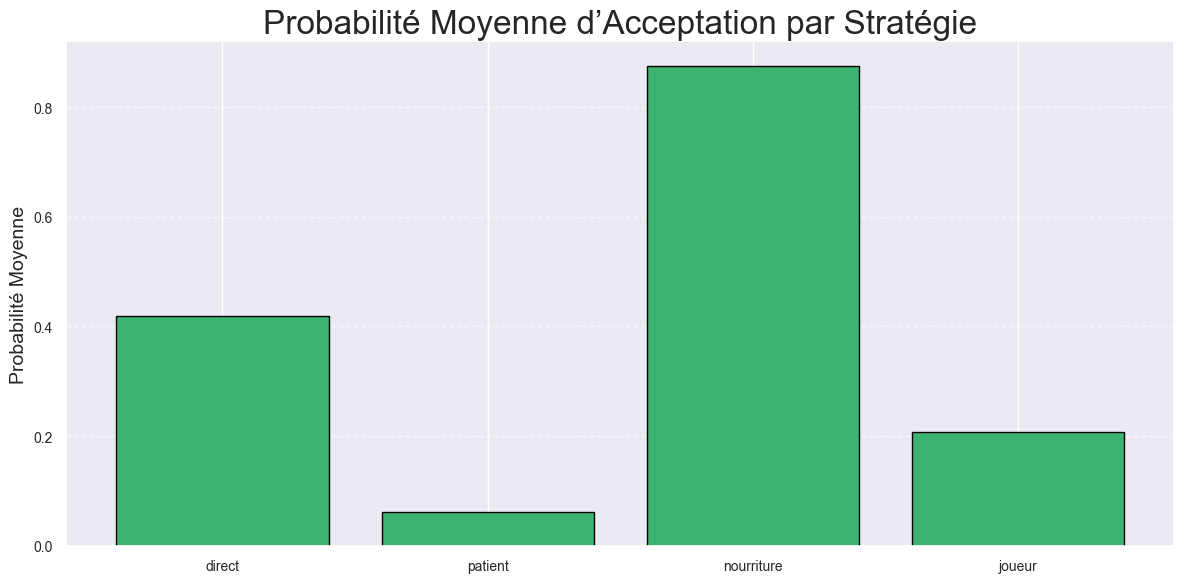

In [16]:
labels = list(resultats_strategies.keys())
moyennes = [np.mean(values) for values in resultats_strategies.values()]

plt.figure(figsize=(12, 6))  # Increased height for better readability

plt.bar(labels, moyennes, color='mediumseagreen', edgecolor='black')

plt.title("Probabilité Moyenne d’Acceptation par Stratégie", fontsize=24)
plt.ylabel("Probabilité Moyenne", fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()


La stratégie "nourriture" a la plus forte probabilité moyenne d'acceptation, tandis que la stratégie "patient" est la moins efficace selon ces données.Ce graphique à barres présente la probabilité moyenne d’acceptation pour quatre stratégies distinctes : direct, patient, nourriture et joueur. On observe une grande disparité entre les stratégies. La stratégie nourriture se démarque très nettement avec une probabilité moyenne proche de 1, ce qui indique qu’elle est largement la plus efficace pour obtenir une acceptation. À l’opposé, les stratégies patient et joueur affichent des probabilités beaucoup plus faibles, révélant leur faible performance globale. La stratégie directe se positionne entre les deux extrêmes, avec un taux d’acceptation modéré. Cette distribution met en lumière des écarts marqués d'efficacité selon l’approche adoptée.



## Statistiques détaillées par stratégie

In [17]:
print("Analyse des stratégies:")
for strategy, values in resultats_strategies.items():
    print(f"\nStratégie '{strategy}':")
    print(f"  Moyenne: {np.mean(values)*100:.2f}%")
    print(f"  Écart-type: {np.std(values)*100:.2f}%")
    print(f"  Min: {min(values)*100:.2f}%, Max: {max(values)*100:.2f}%")
    print(f"  Médiane: {np.median(values)*100:.2f}%")


Analyse des stratégies:

Stratégie 'direct':
  Moyenne: 41.88%
  Écart-type: 32.44%
  Min: 0.00%, Max: 100.00%
  Médiane: 44.21%

Stratégie 'patient':
  Moyenne: 6.15%
  Écart-type: 13.03%
  Min: 0.00%, Max: 67.90%
  Médiane: 0.00%

Stratégie 'nourriture':
  Moyenne: 87.59%
  Écart-type: 20.51%
  Min: 2.03%, Max: 100.00%
  Médiane: 100.00%

Stratégie 'joueur':
  Moyenne: 20.84%
  Écart-type: 26.14%
  Min: 0.00%, Max: 100.00%
  Médiane: 4.30%


<h1 style="color: red;">Session multiple de Simulation et Analyse
</h1>


## Simulation des interactions sur plusieurs sessions

In [18]:
resultats_sessions = simulation.simuler_interactions_multiple_sessions(nombre_personnes=30, sessions_par_personne=8)


## Analyse des moyennes par session

In [19]:
def analyser_sessions_multiples(resultats_par_personne):
    data = np.array(resultats_par_personne)
    moyennes_sessions = np.mean(data, axis=0)
    return data, moyennes_sessions
data, moyennes_sessions = analyser_sessions_multiples(resultats_sessions)


## Évolution de l'Acceptation au Fil des Sessions

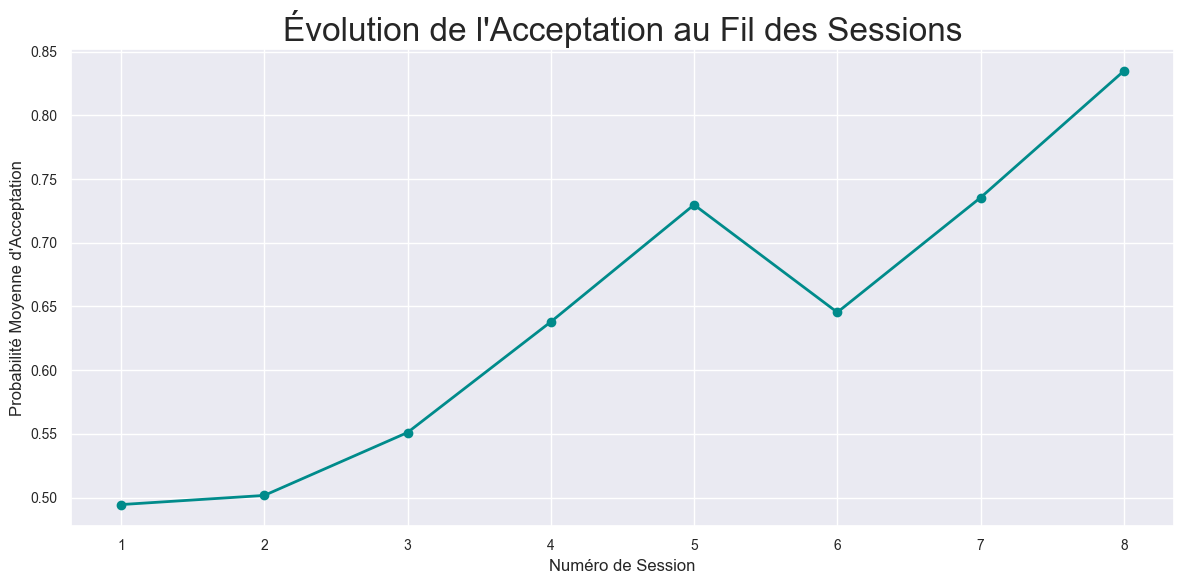

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(moyennes_sessions) + 1), moyennes_sessions, marker='o', color='darkcyan', linewidth=2)
plt.title("Évolution de l'Acceptation au Fil des Sessions", fontsize=24)
plt.xlabel("Numéro de Session")
plt.ylabel("Probabilité Moyenne d'Acceptation")
plt.grid(True)
plt.tight_layout()
plt.show()

Ce graphique en ligne illustre l’évolution de la probabilité moyenne d’acceptation au fil de huit sessions. On y observe une forte variabilité d’une session à l’autre, avec des fluctuations marquées. La probabilité diminue fortement entre la 1ʳᵉ et la 2ᵉ session, puis remonte lors de la 3ᵉ avant de chuter à son minimum à la session 4. À partir de là, une tendance ascendante se dessine jusqu’à la session 6, atteignant un pic élevé, suivie d’un nouveau recul en session 7, puis d’une hausse marquée en session 8, qui présente la valeur la plus élevée du graphique. Cette alternance de hauts et de bas traduit une instabilité dans les performances, suggérant que les conditions ou comportements d’interaction varient fortement entre les sessions.

## Carte de Chaleur des Interactions par Personne et Session

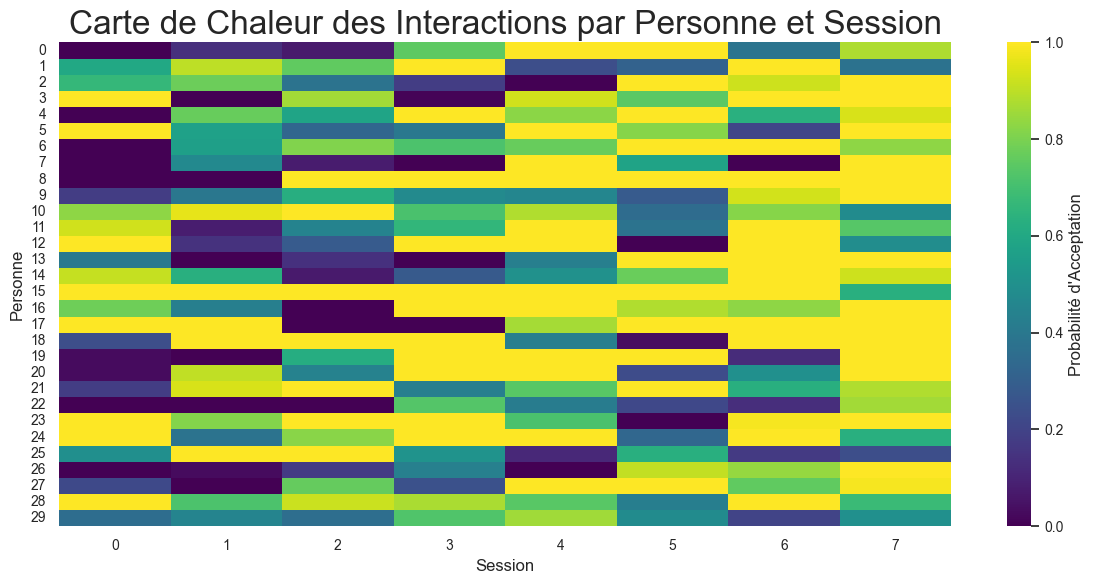

In [21]:
plt.figure(figsize=(12, 6))
plt.title("Carte de Chaleur des Interactions par Personne et Session", fontsize=24)
cmap = sns.color_palette("viridis", as_cmap=True)  # Using 'viridis' for a modern look
ax = sns.heatmap(data, cmap=cmap, vmin=0, vmax=1, cbar_kws={'label': "Probabilité d'Acceptation"})
plt.xlabel("Session")
plt.ylabel("Personne")
plt.tight_layout()
plt.show()


Ce graphique en carte de chaleur représente les probabilités d’acceptation selon les interactions entre différentes personnes (en ordonnée) et sessions (en abscisse). Chaque case colorée reflète une probabilité comprise entre 0 (en violet foncé) et 1 (en jaune vif), selon l’échelle affichée à droite.

On observe une grande hétérogénéité dans les interactions : certaines personnes montrent des probabilités élevées d’acceptation lors de certaines sessions, tandis que d'autres présentent des valeurs faibles, voire nulles. Cette variabilité se manifeste autant d’une personne à l’autre que d’une session à l’autre, traduisant une instabilité notable dans les comportements d’acceptation.

Il n’y a pas de tendance linéaire claire d’amélioration ou de détérioration au fil des sessions. Au contraire, on distingue des pics sporadiques de probabilité élevée dans certaines sessions, parfois suivis de baisses nettes. Cette alternance suggère que des facteurs externes (conditions, contexte, dynamique de groupe, etc.) ou internes (état d’esprit des participants, évolution de la stratégie, etc.) influencent fortement les résultats d’une session à l’autre.

## Analyse des sessions multiples

In [22]:
print("Analyse des sessions multiples:")
print(f"Moyenne globale d'acceptation: {np.mean(data)*100:.2f}%")
progression = (moyennes_sessions[-1] - moyennes_sessions[0])*100
print(f"Progression de la première à la dernière session: {progression:.2f}%")
if moyennes_sessions[-1] > moyennes_sessions[0]:
    print("Tendance générale: Amélioration de l'acceptation au fil des sessions")
else:
    print("Tendance générale: Détérioration ou stagnation de l'acceptation au fil des sessions")

Analyse des sessions multiples:
Moyenne globale d'acceptation: 64.13%
Progression de la première à la dernière session: 34.02%
Tendance générale: Amélioration de l'acceptation au fil des sessions
